# 03 — Group statistics (PRIMARY analysis)

Pre-registered confirmatory statistics on the P300 SWLDA classifier (prerec §5).
Run after notebook 01 has been executed for every subject (writes
`data/derived/classifier-v3/`).

All computation lives in `analysis/classifier.py`; this notebook only calls and
displays, so it is safe to re-run as subjects accumulate.

Plan:
1. **Control ceiling check** — §5 contingency: if mean held-out control accuracy
   < 60%, the classifier analysis becomes descriptive and N170 becomes primary.
2. **Primary (non-parametric):** Friedman across conditions, then one-tailed
   Wilcoxon vs control (predicted: noise *lowers* accuracy).
3. **Robustness (parametric):** RM-ANOVA with corrected Greenhouse-Geisser.
4. **Retention layer** (data survival) and **error-type layer** (false positives)
   as descriptive context; retention test flagged EXPLORATORY.

In [1]:
# ---- CONFIGURE HERE -------------------------------------------------------
DERIVED_DIR = 'data/derived'
ALPHA       = 0.05
# ---------------------------------------------------------------------------

In [2]:
import sys, os
from pathlib import Path
_here = Path('.').resolve()
repo_root = next((p for p in [_here, _here.parent, _here.parent.parent]
                  if (p / 'config.yaml').exists()), _here)
os.chdir(repo_root); sys.path.insert(0, str(repo_root))
print(f'Working directory: {Path.cwd()}')

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams['figure.dpi'] = 120

from analysis.classifier import (
    load_all_results, build_accuracy_dataframe, run_group_statistics,
    check_control_ceiling, load_all_rejection_logs, build_retention_dataframe,
    run_retention_exploratory, CLF_CONDITIONS, RAW_CONDITIONS,
)
from analysis.plots import CONDITION_COLORS
print('Imports OK')

Working directory: G:\Coding_Workspaces_Masters
Imports OK


## 1. Load results + control-ceiling contingency (§5)

In [3]:
results = load_all_results(DERIVED_DIR)
print(f'Found {len(results)} subjects with classifier results.')
if not results:
    raise RuntimeError('No results. Run notebook 01 for each subject first.')

cc = check_control_ceiling(results)
print(f"\nControl ceiling (mean held-out balanced accuracy): "
      f"{cc['mean_control_balanced_accuracy']*100:.1f}%  (n={cc['n']})")
if cc['passes']:
    print(f"PASS (>= {cc['threshold']*100:.0f}%): the classifier analysis is the PRIMARY outcome.")
else:
    print(f"*** BELOW {cc['threshold']*100:.0f}% -- per prerec §5 the classifier analysis "
          f"becomes DESCRIPTIVE and N170 becomes PRIMARY. ***")

Found 32 subjects with classifier results.

Control ceiling (mean held-out balanced accuracy): 89.3%  (n=32)
PASS (>= 60%): the classifier analysis is the PRIMARY outcome.


## 2. Descriptives

In [4]:
df = build_accuracy_dataframe(results)
desc = (df.groupby('condition')['balanced_accuracy']
          .agg(['count', 'mean', 'std', 'median']).round(2)
          .reindex(CLF_CONDITIONS))
desc.columns = ['N', 'Mean %', 'SD %', 'Median %']
print('Balanced accuracy by condition:')
print(desc.to_string())

Balanced accuracy by condition:
                  N  Mean %   SD %  Median %
condition                                   
control_heldout  32   89.33   4.92     90.44
chewing          32   83.73   6.09     84.36
emi              32   86.22  10.80     89.62
acoustic         32   88.50   7.73     90.16


## 3. Subject × condition accuracy table

In [5]:
table = df.pivot(index='subject', columns='condition', values='balanced_accuracy')
table = table[CLF_CONDITIONS].round(1)
table.loc['MEAN'] = table.mean().round(1)
table.loc['SD']   = table.iloc[:-1].std().round(1)
table

condition,control_heldout,chewing,emi,acoustic
subject,,,,
01,93.4,93.5,97.3,96.6
02,80.8,80.1,88.1,90.4
03,91.5,84.0,90.9,93.4
04,84.6,77.1,72.1,59.8
05,88.5,90.6,89.2,91.1
06,83.2,73.9,83.3,73.9
07,88.8,81.3,92.1,86.8
08,90.0,86.0,91.7,90.0
09,96.4,93.0,95.8,97.4


## 4. Primary statistics — Friedman + Wilcoxon + RM-ANOVA(GG)

In [6]:
stats = run_group_statistics(results)
print(f'N (complete cases): {stats["n_subjects"]}\n')

fr = stats['friedman']
print(f'Friedman:  chi2({fr["df"]}) = {fr["statistic"]:.3f},  p = {fr["p_value"]:.4g}'
      f'   [{"SIGNIFICANT" if fr["p_value"] < ALPHA else "n.s."} at a={ALPHA}]\n')

print('Wilcoxon post-hoc vs control  (one-tailed: noise < control):')
print(f'{"cond":<10}{"W":>8}{"p(1)":>11}{"p(2)":>11}{"dz":>8}{"95% CI":>18}{"meanD":>9}')
print('-' * 75)
for c, ph in stats['wilcoxon_posthoc_vs_control'].items():
    mark = '*' if ph['p_one_tailed'] < ALPHA else ' '
    ci = f'[{ph["ci_low"]:+.2f},{ph["ci_high"]:+.2f}]'
    print(f'{c:<10}{ph["wilcoxon_statistic"]:>8.1f}{ph["p_one_tailed"]:>11.4g}'
          f'{ph["p_two_tailed"]:>11.4g}{ph["cohens_d"]:>8.2f}{ci:>18}'
          f'{ph["mean_diff"]:>+9.2f} {mark}')
print(f'  * p < {ALPHA} (one-tailed).  dz < 0 = noise degrades accuracy.\n')

rm = stats['rm_anova']
if 'error' in rm:
    print('RM-ANOVA error:', rm['error'])
else:
    print('RM-ANOVA (robustness, corrected Greenhouse-Geisser):')
    print(f'  F({rm["df_numerator"]:.0f}, {rm["df_denominator"]:.0f}) = {rm["f_statistic"]:.3f},  '
          f'p(uncorr) = {rm["p_uncorrected"]:.4g}')
    print(f'  GG epsilon = {rm["greenhouse_geisser_epsilon"]:.3f}  ->  '
          f'F({rm["df_numerator_gg"]:.2f}, {rm["df_denominator_gg"]:.2f}),  '
          f'p(GG) = {rm["p_greenhouse_geisser"]:.4g}')

N (complete cases): 32

Friedman:  chi2(3) = 25.950,  p = 9.77e-06   [SIGNIFICANT at a=0.05]

Wilcoxon post-hoc vs control  (one-tailed: noise < control):
cond             W       p(1)       p(2)      dz            95% CI    meanD
---------------------------------------------------------------------------
chewing       17.0   4.82e-08  9.639e-08   -1.10     [-1.56,-0.65]    -5.61 *
emi          216.0     0.1897     0.3794   -0.30     [-0.67,+0.07]    -3.12  
acoustic     242.0     0.3458     0.6916   -0.15     [-0.51,+0.21]    -0.83  
  * p < 0.05 (one-tailed).  dz < 0 = noise degrades accuracy.

RM-ANOVA (robustness, corrected Greenhouse-Geisser):
  F(3, 93) = 5.955,  p(uncorr) = 0.0009269
  GG epsilon = 0.617  ->  F(1.85, 57.35),  p(GG) = 0.00544


## 5. Parametric vs non-parametric agreement (§5)

In [7]:
fr_sig = stats['friedman']['p_value'] < ALPHA
rm = stats['rm_anova']
rm_sig = (rm.get('p_greenhouse_geisser', 1.0) < ALPHA) if 'error' not in rm else None
print(f'Friedman:      {"SIGNIFICANT" if fr_sig else "n.s."}')
if rm_sig is not None:
    print(f'RM-ANOVA(GG):  {"SIGNIFICANT" if rm_sig else "n.s."}')
    print('\nAgreement between parametric and non-parametric.' if fr_sig == rm_sig
          else '\nDISAGREEMENT — report both, discuss distributional assumptions.')

Friedman:      SIGNIFICANT
RM-ANOVA(GG):  SIGNIFICANT

Agreement between parametric and non-parametric.


## 6. Effect-size forest plot

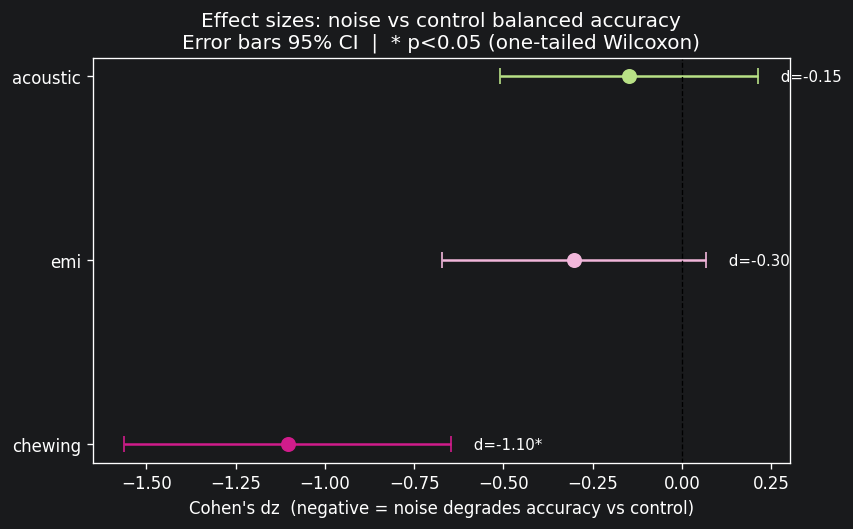

In [8]:
noise = [c for c in CLF_CONDITIONS if c != 'control_heldout']
fig, ax = plt.subplots(figsize=(7, max(3, len(noise) * 1.1 + 1)), layout='constrained')
for y, c in enumerate(noise):
    ph = stats['wilcoxon_posthoc_vs_control'][c]
    d, lo, hi = ph['cohens_d'], ph['ci_low'], ph['ci_high']
    ax.errorbar(d, y, xerr=[[d - lo], [hi - d]], fmt='o', capsize=5, linewidth=1.5,
                color=CONDITION_COLORS.get(c, '#888888'), markersize=8)
    star = '*' if ph['p_one_tailed'] < ALPHA else ''
    ax.text(hi + 0.05, y, f' d={d:.2f}{star}', va='center', fontsize=9)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_yticks(range(len(noise))); ax.set_yticklabels(noise)
ax.set_xlabel("Cohen's dz  (negative = noise degrades accuracy vs control)")
ax.set_title('Effect sizes: noise vs control balanced accuracy\n'
             f'Error bars 95% CI  |  * p<{ALPHA} (one-tailed Wilcoxon)')
plt.show()

## 7. Retention layer (data survival)

Descriptive context. The test below is **EXPLORATORY** — per §5 raw signal
quality / rejection rate is descriptive, not a registered inferential outcome.
This is where chewing's primary damage lives: data destroyed before the
classifier ever runs.

In [9]:
logs = load_all_rejection_logs(DERIVED_DIR)
if not logs:
    print('No rejection logs under preprocessing-v2/. Skipping retention layer.')
else:
    rdf = build_retention_dataframe(logs)
    order = [c for c in RAW_CONDITIONS if c in rdf['condition'].unique()]
    rtab = (rdf.groupby('condition')[['retention_rate', 'rejection_rate']]
              .mean().round(1).reindex(order))
    rtab.columns = ['Retention %', 'Rejection %']
    print('Mean retention / rejection by condition:')
    print(rtab.to_string()); print()
    expl = run_retention_exploratory(logs)
    if 'friedman' in expl:
        print(f'[EXPLORATORY] Friedman on rejection rate: '
              f'chi2={expl["friedman"]["statistic"]:.2f}, p={expl["friedman"]["p_value"]:.4g}')
        for c, ph in expl['wilcoxon_posthoc_vs_control'].items():
            print(f'  {c:9s} mean rejection={ph["mean_rejection"]:.1f}%  '
                  f'p(1-tail, noise>control)={ph["p_one_tailed_vs_control"]:.4g}')
        print('  (EXPLORATORY: descriptive context per §5, not a registered inferential test.)')
    else:
        print(expl.get('note', ''))

Mean retention / rejection by condition:
           Retention %  Rejection %
condition                          
control           98.1          1.9
chewing           71.0         29.0
emi               96.3          3.7
acoustic          96.1          3.9

[EXPLORATORY] Friedman on rejection rate: chi2=88.21, p=5.304e-19
  chewing   mean rejection=29.0%  p(1-tail, noise>control)=2.328e-10
  emi       mean rejection=3.7%  p(1-tail, noise>control)=3.509e-07
  acoustic  mean rejection=3.9%  p(1-tail, noise>control)=3.237e-07
  (EXPLORATORY: descriptive context per §5, not a registered inferential test.)


## 8. Error-type layer (false positives)

Descriptive. False-positive rate = 100 − specificity. A chewing FPR markedly
above control indicates EMG mimicry of the P300 (false alarms) — a distinct
failure mode from the data loss seen in the retention layer.

In [10]:
err = (df.groupby('condition')[['sensitivity', 'specificity', 'false_positive_rate']]
         .mean().round(1).reindex(CLF_CONDITIONS))
err.columns = ['Sensitivity %', 'Specificity %', 'False-positive rate %']
print('Mean error profile by condition:')
print(err.to_string())

Mean error profile by condition:
                 Sensitivity %  Specificity %  False-positive rate %
condition                                                           
control_heldout           85.2           93.5                    6.5
chewing                   79.5           88.0                   12.0
emi                       79.5           93.0                    7.0
acoustic                  83.8           93.2                    6.8
